In [50]:
# If neccesary install once:
#!pip install matplotlib numpy
from energymap4py import ai_model as em_model
from energymap4py import data_access as em_data
import matplotlib.pyplot as plt
import numpy as np

# EnergyMap Berlin prognosis model
## This example shows how parameter values (features) of a building can be varied to obtain energy demand values using the AI prognosis model.

The considered building is the main adminstration building of the UdK Berlin, located at Einsteinufer 43 - 53, 10587 Berlin.

<img src="img/UdKB_building.png" width="500">

This building is assigned in the EnergyMap Berlin database wit the building UUID 'DEBE04YY500002vO'.

### Some basic information about these building

In [ ]:
info = em_data.by_uuid('DEBE04YY500002vO')
print('Year of construction:',info[0]['year_of_construction'])
print('Heritage type:',info[0]['heritage_type'])
print('Building ground area:',info[0]['ground_area'], 'm2')

### Yearly heating demand of the building (climate corrected and for different historical climate years

https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2015&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2016&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2017&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2018&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2019&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2020&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2021&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&clim_year=2022&plant_eff=0.93&hwd=25


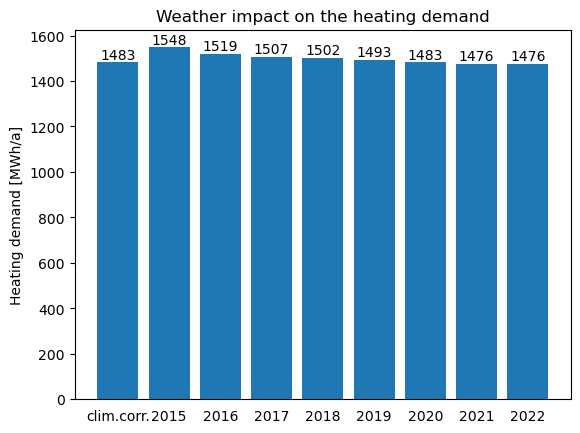

In [52]:
values = []
values.append(em_model.predict('DEBE04YY500002vO')[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2015)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2016)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2017)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2018)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2019)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2020)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2021)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',climate_year=2022)[0]['heat_demand']/1000)
years = ('clim.corr.','2015','2016','2017','2018','2019','2020','2021','2022')
 
y_pos = np.arange(len(years))
bars = plt.bar(y_pos, values, align='center')
plt.xticks(y_pos, years)
plt.ylabel('Heating demand [MWh/a]')
plt.title('Weather impact on the heating demand')
# Striche auf x-Achse ausschalten
plt.tick_params(
    axis='x',
    which='both',
    bottom=False)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')
plt.show()


### Refurbishment of the building

The building is refurbished in three steps: 

1st step: Insulation of the opaque facade (original U-value: 2.89 W/m2K, insulated facade U-value: 0.25 W/m2K)
2nd step: Exchange of the old windows against triple glaze windows (original U-value: 2.8 W/m2K, insulated facade U-value: 0.9 W/m2K)
3rd step: Insulation of the roof (original U-value: 0.99 W/m2K, insulated facade U-value: 0.2 W/m2K)

https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&wall_uval=0.25&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&wall_win_uval=0.9&wall_uval=0.25&plant_eff=0.93&hwd=25
https://energymap-berlin.de/model/nn?uuid=DEBE04YY500002vO&bldg_type=GMH&wall_win_uval=0.9&wall_uval=0.25&ceil_uval=0.2&plant_eff=0.93&hwd=25
[1483.685546405293, 1410.0125297443383, 1408.2420813865244, 1283.2718432864722]


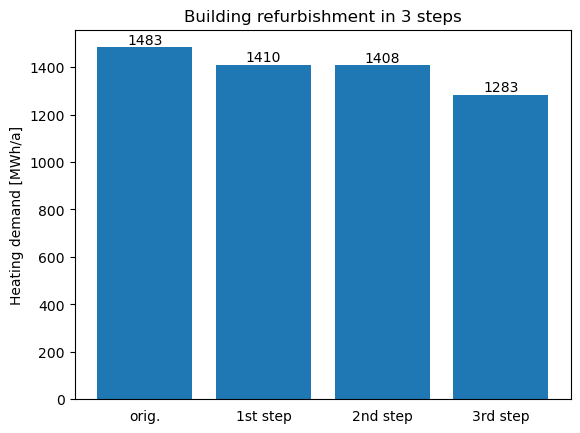

In [49]:
values = []
values.append(em_model.predict('DEBE04YY500002vO')[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',outwalls_uvalue=0.25)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',outwalls_uvalue=0.25,outwalls_window_uvalue=0.9)[0]['heat_demand']/1000)
values.append(em_model.predict('DEBE04YY500002vO',outwalls_uvalue=0.25,outwalls_window_uvalue=0.9,top_ceiling_uvalue=0.2)[0]['heat_demand']/1000)

steps = ('orig.','1st step','2nd step','3rd step')
 
y_pos = np.arange(len(steps))
bars = plt.bar(y_pos, values, align='center')
plt.xticks(y_pos, steps)
plt.ylabel('Heating demand [MWh/a]')
plt.title('Building refurbishment in 3 steps')
# Striche auf x-Achse ausschalten
plt.tick_params(
    axis='x',
    which='both',
    bottom=False)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')
plt.show()
